In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
#Data import and initial display
GlobalYLL_df = pd.read_csv("IHME_EUROPE_AMR_2019_YLLS_Y2022M10D13.csv")
display(GlobalYLL_df)

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_group_id,age_group_name,cause_id,cause_name,...,metric_id,metric_name,infectious_syndrome,infsyn_name_short,pathogen,antibiotic_class,counterfactual,val,upper,lower
0,4,YLLs (Years of Life Lost),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,Drug-susceptible infection,2.669730e+00,6.551897e+00,0.000000e+00
1,4,YLLs (Years of Life Lost),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,No infection,6.270925e+01,9.428190e+01,3.834576e+01
2,4,YLLs (Years of Life Lost),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,Drug-susceptible infection,2.900869e+00,5.778421e+00,1.293739e+00
3,4,YLLs (Years of Life Lost),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,No infection,7.420341e+01,1.114949e+02,4.656333e+01
4,4,YLLs (Years of Life Lost),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Beta Lactam/Beta-lactamase inhibitors,Drug-susceptible infection,5.819828e-03,4.343237e-02,2.429510e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838667,4,YLLs (Years of Life Lost),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Resistance to one or more antibiotics,No infection,1.730000e-05,3.140000e-05,8.350000e-06
838668,4,YLLs (Years of Life Lost),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,Drug-susceptible infection,6.360000e-08,1.310000e-07,2.520000e-08
838669,4,YLLs (Years of Life Lost),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,No infection,6.620000e-07,1.220000e-06,3.250000e-07
838670,4,YLLs (Years of Life Lost),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Vancomycin,Drug-susceptible infection,9.570000e-08,2.060000e-07,3.680000e-08


In [3]:
#dtypes. Does the date column need to be changed? Maybe in Tableau is easier or come back and do it here later. 

GlobalYLL_df.dtypes

measure_id               int64
measure_name            object
location_id              int64
location_name           object
sex_id                   int64
sex_name                object
age_group_id             int64
age_group_name          object
cause_id                 int64
cause_name              object
year_id                  int64
metric_id                int64
metric_name             object
infectious_syndrome     object
infsyn_name_short       object
pathogen                object
antibiotic_class        object
counterfactual          object
val                    float64
upper                  float64
lower                  float64
dtype: object

In [4]:
#missing values. There are no missing values. 
pd.DataFrame(GlobalYLL_df.isnull().sum(),columns=['Missing Values'])

,Missing Values
measure_id,0
measure_name,0
location_id,0
location_name,0
sex_id,0
sex_name,0
age_group_id,0
age_group_name,0
cause_id,0
cause_name,0


In [8]:
#summary stats. outliers exist as there are very large and very small mins which indicates that there may be some outliers happening. 
#maybe box plot it or correlate it? 
GlobalYLL_df.describe()

,measure_id,location_id,sex_id,age_group_id,cause_id,year_id,metric_id,val,upper,lower
count,838672.0,838672.000000,838672.0,838672.000000,838672.0,838672.0,838672.000000,8.386720e+05,8.386720e+05,8.386720e+05
mean,4.0,77.905660,3.0,53.080637,294.0,2019.0,2.000000,4.760992e+02,7.449010e+02,2.864115e+02
std,0.0,64.338256,0.0,71.116271,0.0,0.0,1.000001,9.410759e+03,1.395160e+04,6.039553e+03
min,4.0,33.000000,3.0,4.000000,294.0,2019.0,1.000000,1.000000e-66,4.680000e-66,0.000000e+00
25%,4.0,48.000000,3.0,5.000000,294.0,2019.0,1.000000,3.860000e-06,9.070000e-06,5.740000e-07
50%,4.0,62.000000,3.0,22.000000,294.0,2019.0,2.000000,7.627640e-04,1.761508e-03,1.117260e-04
75%,4.0,85.000000,3.0,42.000000,294.0,2019.0,3.000000,1.641883e+00,3.710451e+00,4.085828e-01
max,4.0,396.000000,3.0,192.000000,294.0,2019.0,3.000000,2.831700e+06,4.042645e+06,1.905248e+06


In [11]:
#checking years to see if there are different years and to see how the values are listed and if they need to be changed to a different date type. 
GlobalYLL_df.year_id

0         2019
1         2019
2         2019
3         2019
4         2019
          ... 
838667    2019
838668    2019
838669    2019
838670    2019
838671    2019
Name: year_id, Length: 838672, dtype: int64

In [ ]:
#check in excel to see how many years of data there are and if you can do a year by year analysis. 
#checked only 2019 data avaialble so you cannot analyze by time. months are also not indicated so no time change possible. 

Text(0, 0.5, 'YLL')

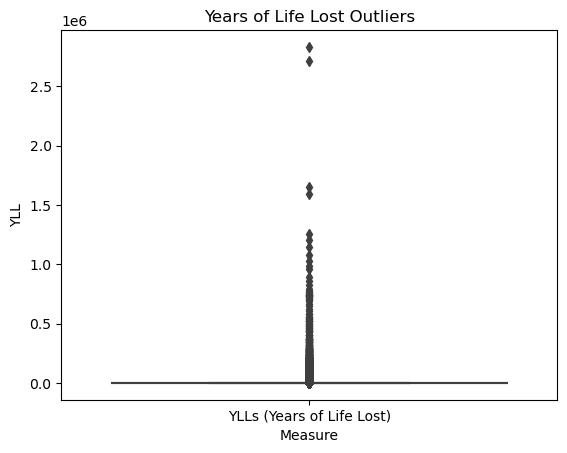

In [12]:
#boxplot to see outliers for the YLL values
sns.boxplot(GlobalYLL_df, x="measure_name", y="val")
plt.title("Years of Life Lost Outliers") 
plt.xlabel("Measure")
plt.ylabel("YLL")

Text(0, 0.5, 'YLL')

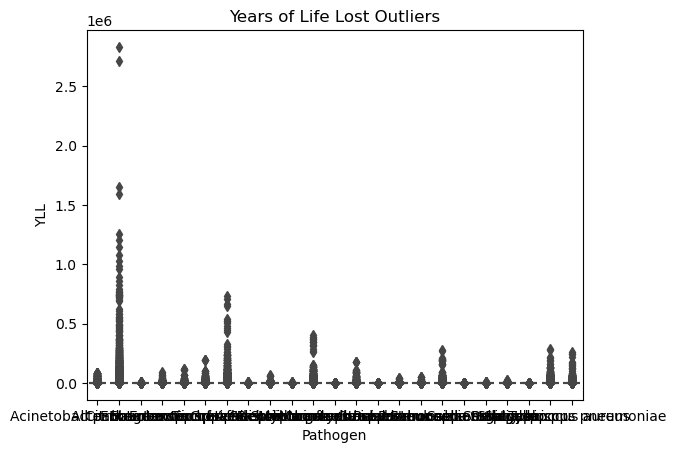

In [13]:
sns.boxplot(GlobalYLL_df, x="pathogen", y="val")
plt.title("Years of Life Lost Outliers") 
plt.xlabel("Pathogen")
plt.ylabel("YLL")

C:\Users\nagpa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


MemoryError: 

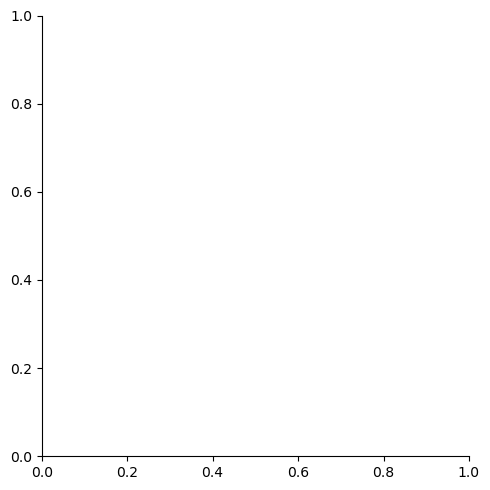

In [14]:
sns.displot(data=GlobalYLL_df, x="val")
plt.title("Unemployment Rate Frequency")
plt.xlabel("Unemployment Percentage") 
plt.ylabel("Count of Unemployment Percentage")

Text(0, 0.5, 'YLL')

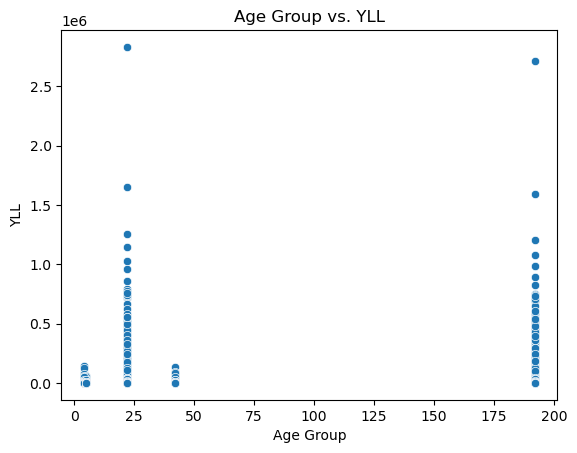

In [16]:
sns.scatterplot(GlobalYLL_df, x="age_group_id", y="val")
plt.title("Age Group vs. YLL") 
plt.xlabel("Age Group")
plt.ylabel("YLL")

Text(0, 0.5, 'YLL')

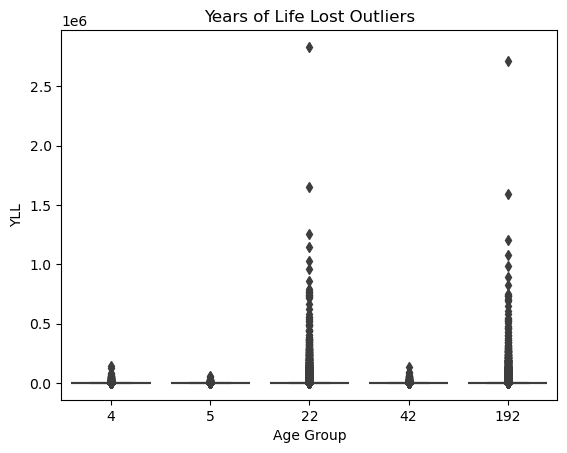

In [17]:
sns.boxplot(GlobalYLL_df, x="age_group_id", y="val")
plt.title("Years of Life Lost Outliers") 
plt.xlabel("Age Group")
plt.ylabel("YLL")

In [20]:
#checking for duplicates. duplicates will not matter in this case because the same illness, same pathogen, etc is possible. 
GlobalYLL_df.duplicated

<bound method DataFrame.duplicated of         measure_id               measure_name  location_id location_name  \
0                4  YLLs (Years of Life Lost)           33       Armenia   
1                4  YLLs (Years of Life Lost)           33       Armenia   
2                4  YLLs (Years of Life Lost)           33       Armenia   
3                4  YLLs (Years of Life Lost)           33       Armenia   
4                4  YLLs (Years of Life Lost)           33       Armenia   
...            ...                        ...          ...           ...   
838667           4  YLLs (Years of Life Lost)          396    San Marino   
838668           4  YLLs (Years of Life Lost)          396    San Marino   
838669           4  YLLs (Years of Life Lost)          396    San Marino   
838670           4  YLLs (Years of Life Lost)          396    San Marino   
838671           4  YLLs (Years of Life Lost)          396    San Marino   

        sex_id sex_name  age_group_id age_group_n

In [21]:
#duplicates corrected. no duplicates. other cleaning and review in python. 
GlobalYLL_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
838667    False
838668    False
838669    False
838670    False
838671    False
Length: 838672, dtype: bool

In [ ]:
#bar graph by pathogen average YLL? 

Text(0, 0.5, 'YLL')

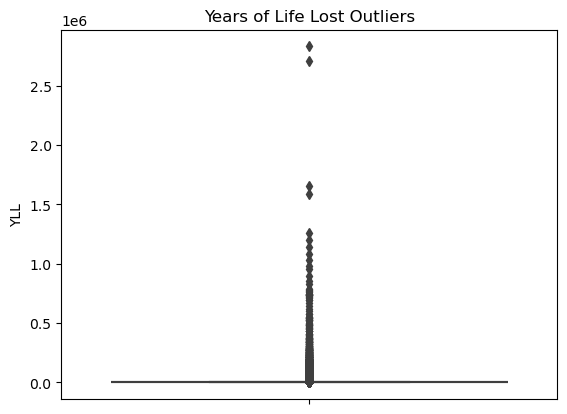

In [22]:
sns.boxplot(GlobalYLL_df, y="val")
plt.title("Years of Life Lost Outliers") 
plt.ylabel("YLL")

In [ ]:
sns.boxplot(GlobalYLL_df, x="age_group_id", y="val")
plt.title("Years of Life Lost Outliers") 
plt.xlabel("Age Group")
plt.ylabel("YLL")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


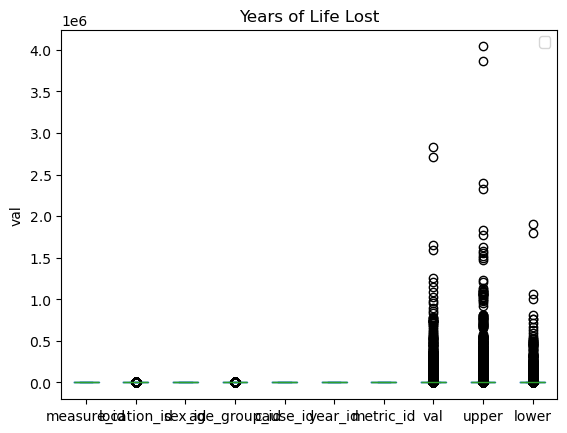

In [45]:
GlobalYLL_df.plot( kind = 'box')
plt.ylabel('val')
plt.title('Years of Life Lost')
plt.legend()
plt.show()

ValueError: Number of rows must be a positive integer, not 'val'

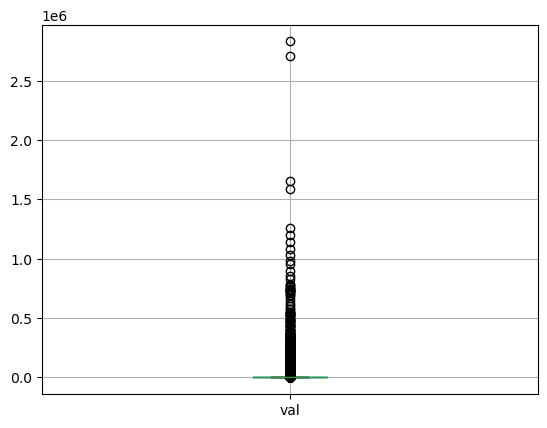

<Figure size 640x480 with 0 Axes>

In [34]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])
    fig, ax = plt.subplots("val")

<Axes: >

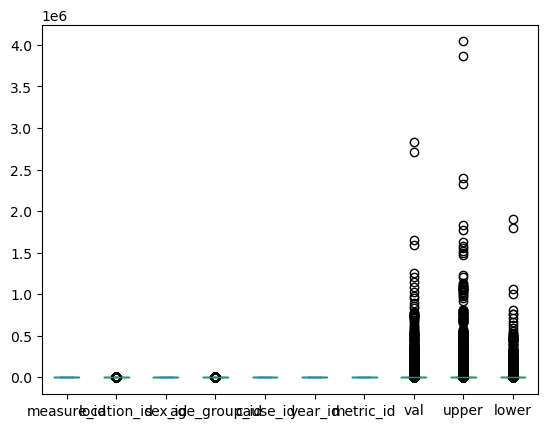

In [29]:
GlobalYLL_df.plot(kind='box')

In [ ]:
Number of rows must be a positive integer, not 'val'

ValueError: Number of rows must be a positive integer, not '838672'

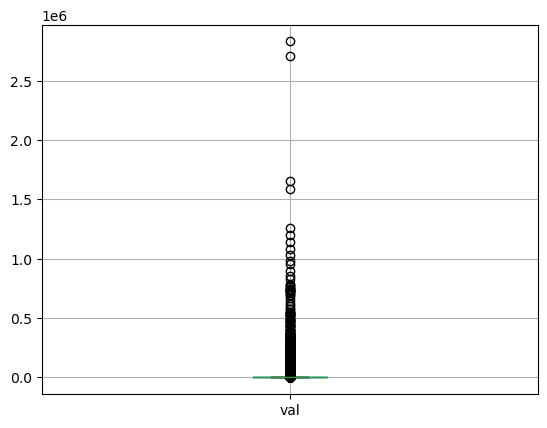

<Figure size 640x480 with 0 Axes>

In [35]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])
    fig, ax = plt.subplots("838672")

In [ ]:
#information gleaned. Boxplots have too many values so it's difficult to assess anything from it without being able to see the plot. 

ValueError: Number of rows must be a positive integer, not '2000'

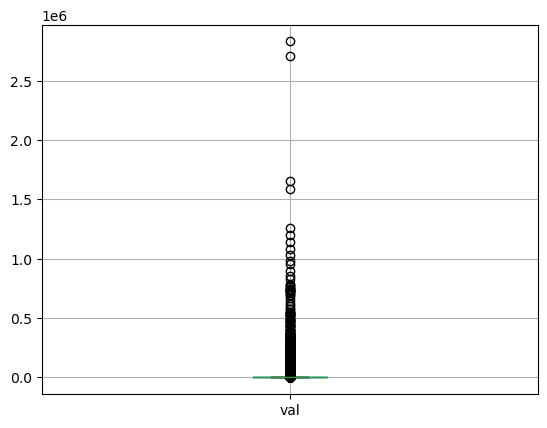

<Figure size 640x480 with 0 Axes>

In [36]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])
    fig, ax = plt.subplots("2000")

In [37]:
GlobalYLL_df.val = GlobalYLL_df.val.astype(int)

C:\Users\nagpa\AppData\Local\Temp\ipykernel_148120\2657420085.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


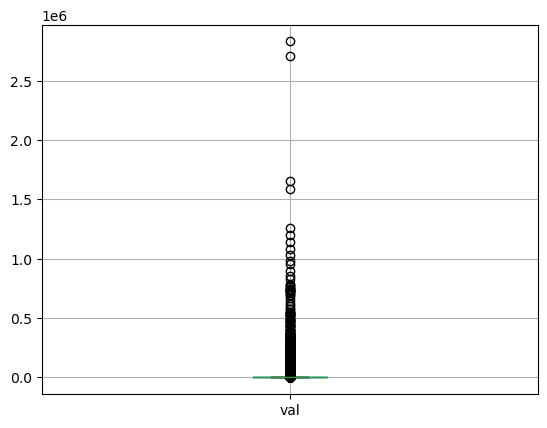

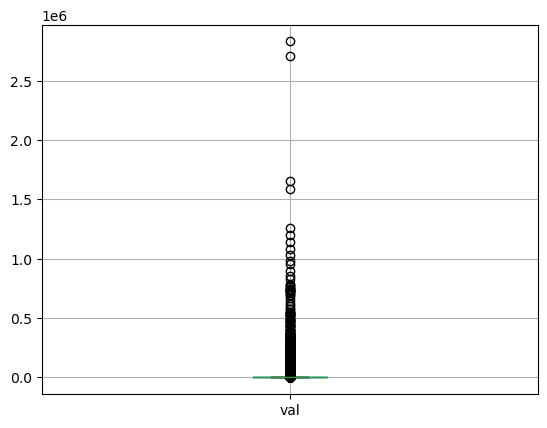

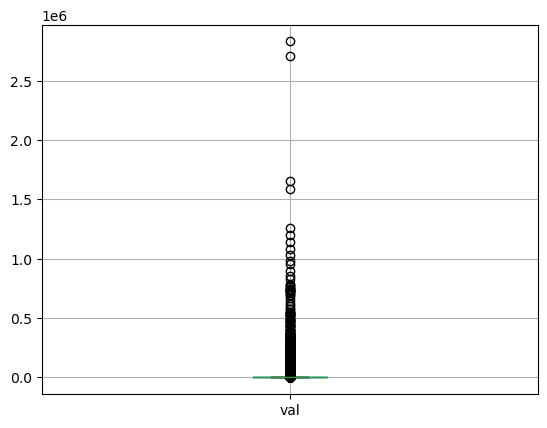

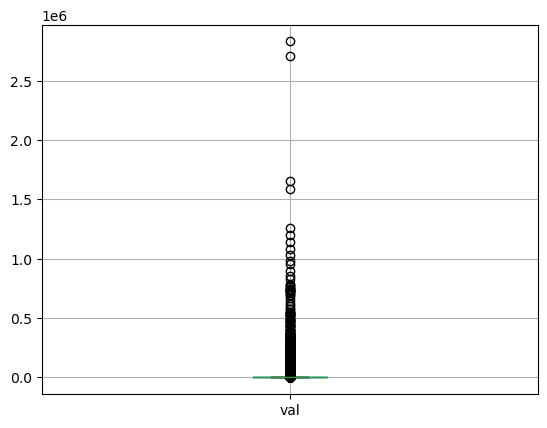

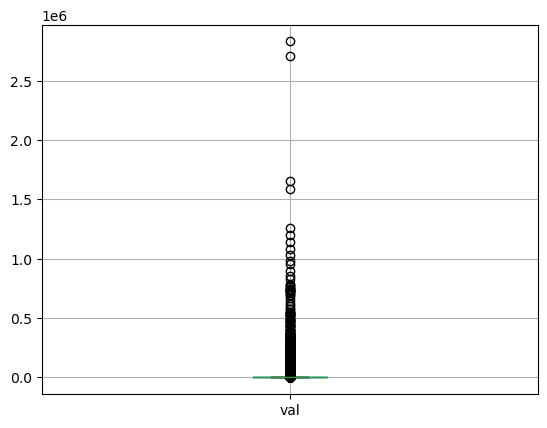

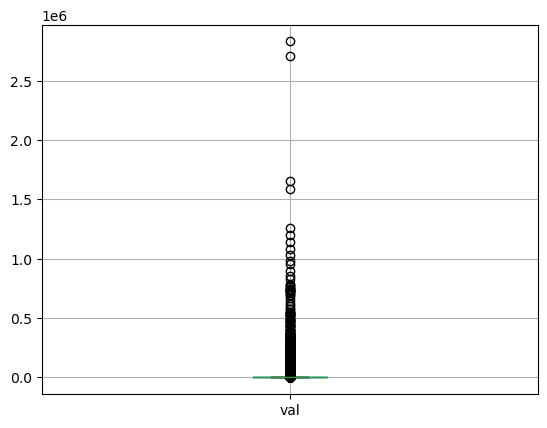

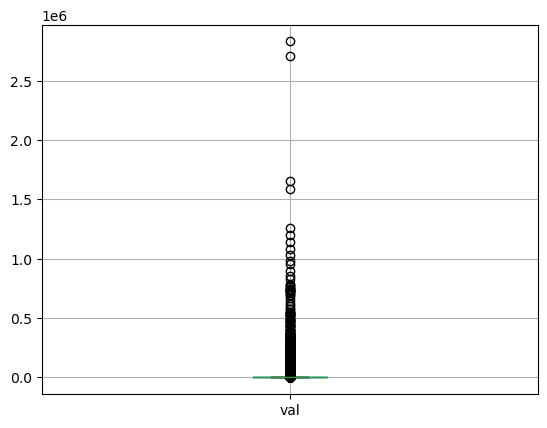

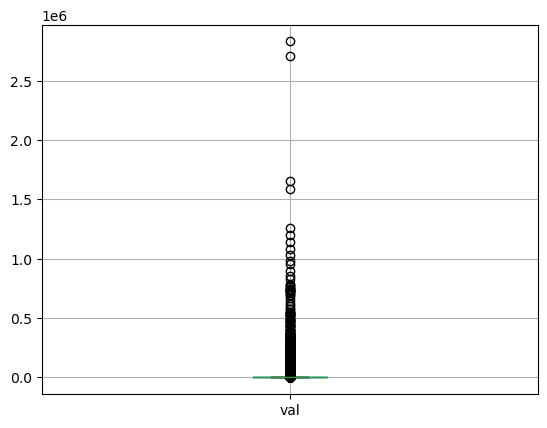

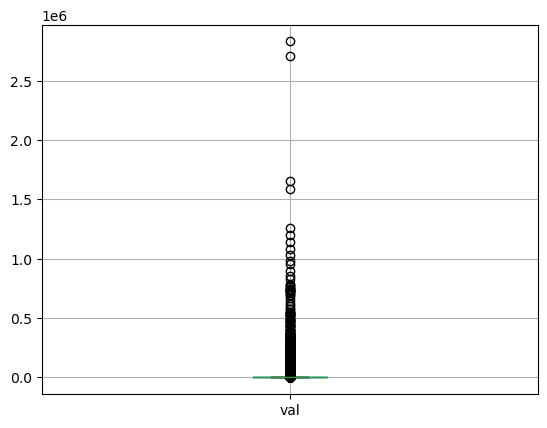

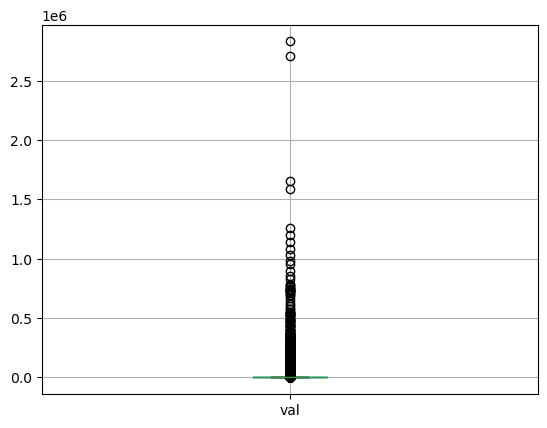

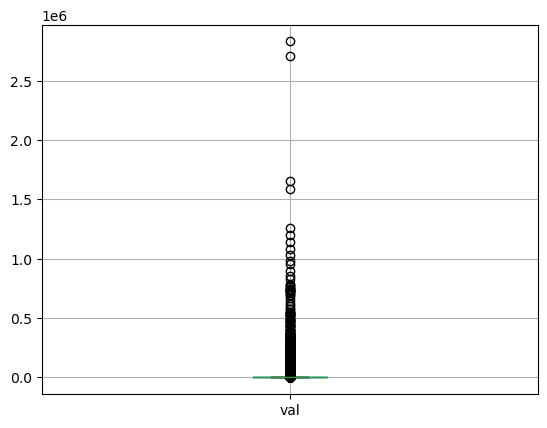

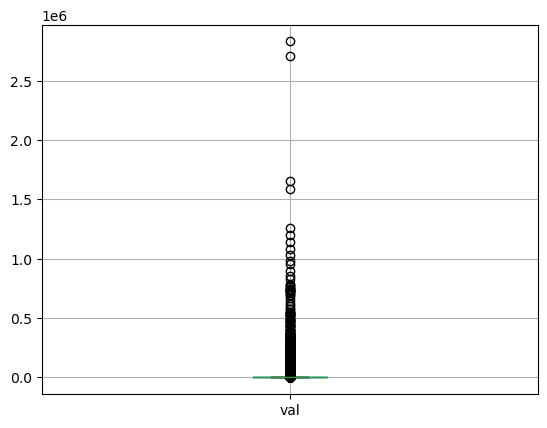

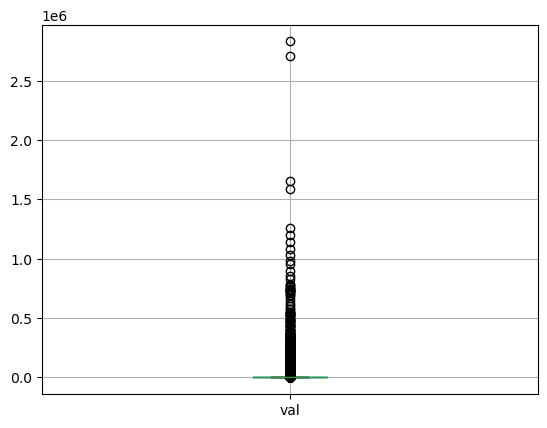

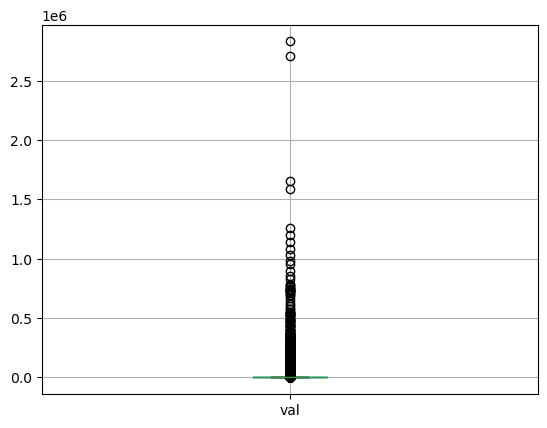

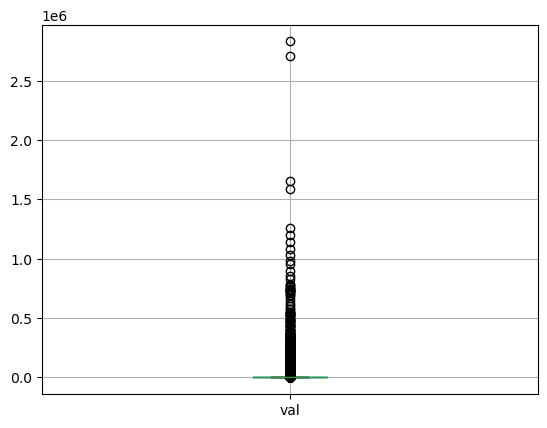

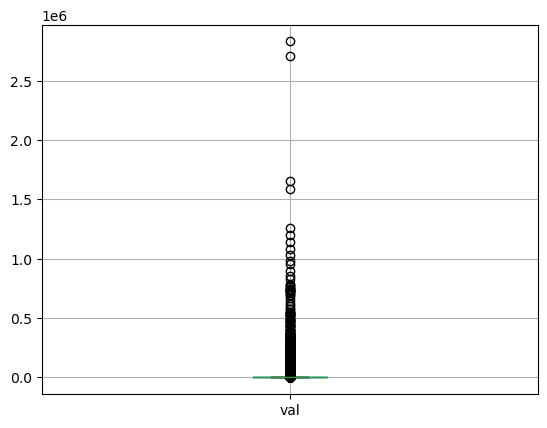

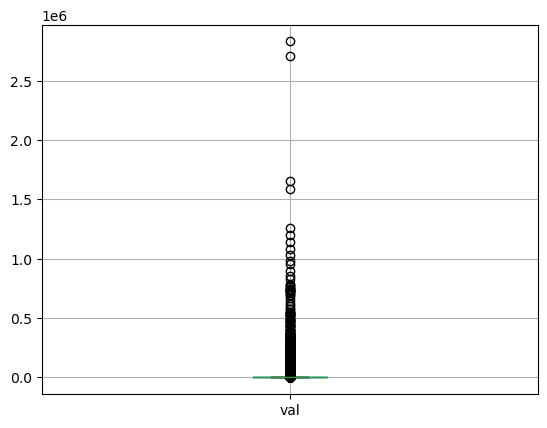

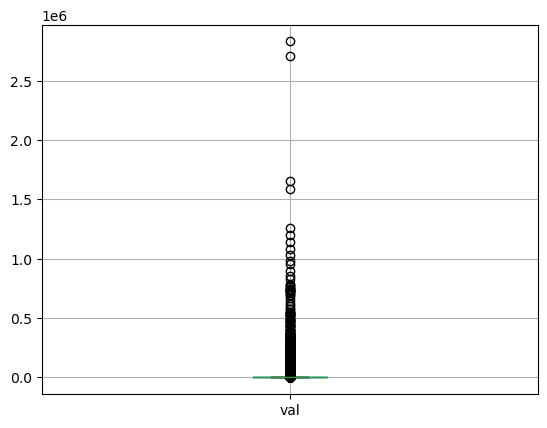

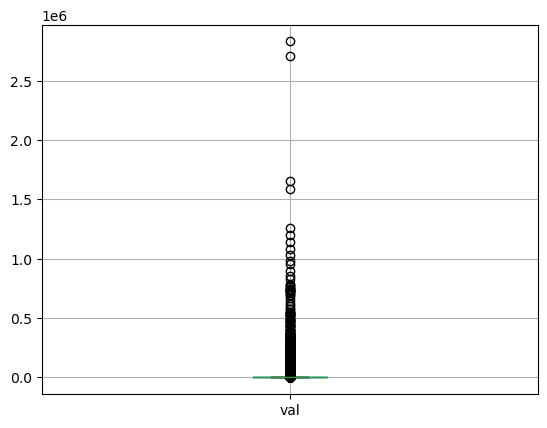

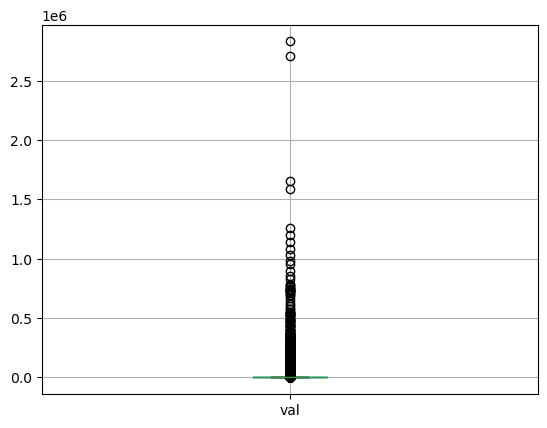

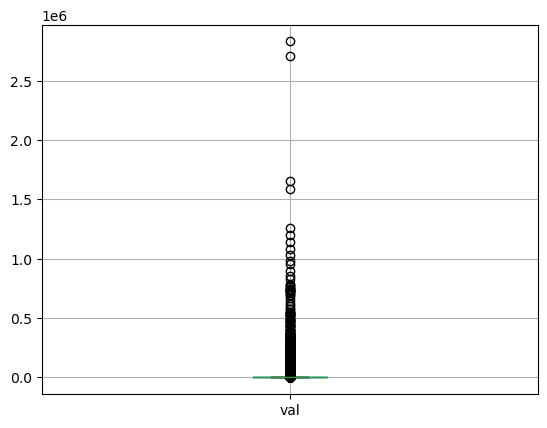

In [38]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])

In [39]:
GlobalYLL_df.dtypes

measure_id               int64
measure_name            object
location_id              int64
location_name           object
sex_id                   int64
sex_name                object
age_group_id             int64
age_group_name          object
cause_id                 int64
cause_name              object
year_id                  int64
metric_id                int64
metric_name             object
infectious_syndrome     object
infsyn_name_short       object
pathogen                object
antibiotic_class        object
counterfactual          object
val                      int32
upper                  float64
lower                  float64
dtype: object

ValueError: Number of rows must be a positive integer, not '2000'

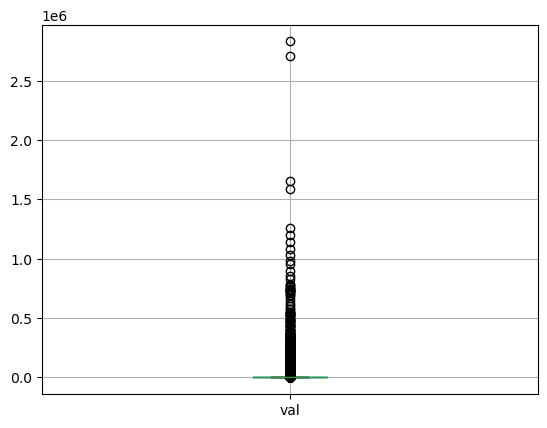

<Figure size 640x480 with 0 Axes>

In [40]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])
    fig, ax = plt.subplots("2000")

ValueError: Number of rows must be a positive integer, not '1'

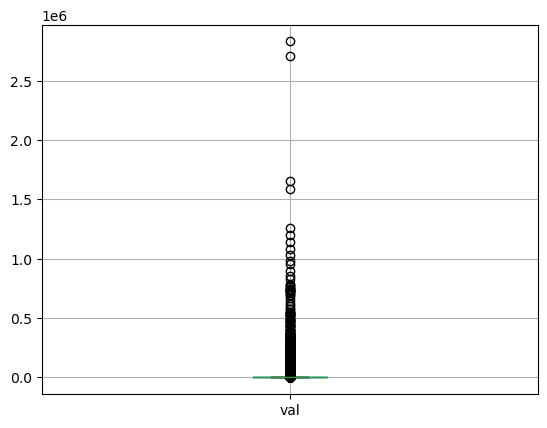

<Figure size 640x480 with 0 Axes>

In [41]:
for val in GlobalYLL_df:
    plt.figure()
    GlobalYLL_df.boxplot(["val"])
    fig, ax = plt.subplots("1")

In [43]:
GlobalYLDs_df = pd.read_csv("IHME_EUROPE_AMR_2019_YLDS_Y2022M10D13.csv")
display(GlobalYLDs_df)

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_group_id,age_group_name,cause_id,cause_name,...,metric_id,metric_name,infectious_syndrome,infsyn_name_short,pathogen,antibiotic_class,counterfactual,val,upper,lower
0,3,YLDs (Years Lived with Disability),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,Drug-susceptible infection,4.083598e-03,1.054816e-02,1.522051e-03
1,3,YLDs (Years Lived with Disability),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,No infection,4.358814e-02,1.093261e-01,1.750468e-02
2,3,YLDs (Years Lived with Disability),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,Drug-susceptible infection,1.531945e-03,4.032497e-03,4.094200e-04
3,3,YLDs (Years Lived with Disability),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,No infection,5.052637e-02,1.268127e-01,2.025665e-02
4,3,YLDs (Years Lived with Disability),33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Beta Lactam/Beta-lactamase inhibitors,Drug-susceptible infection,1.830000e-06,1.350000e-05,7.240000e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848631,3,YLDs (Years Lived with Disability),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Resistance to one or more antibiotics,No infection,8.070000e-07,1.690000e-06,3.220000e-07
848632,3,YLDs (Years Lived with Disability),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,Drug-susceptible infection,1.160000e-09,5.210000e-09,0.000000e+00
848633,3,YLDs (Years Lived with Disability),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,No infection,2.910000e-08,6.460000e-08,1.080000e-08
848634,3,YLDs (Years Lived with Disability),396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Vancomycin,Drug-susceptible infection,4.280000e-09,1.130000e-08,1.170000e-09


In [44]:
GlobalYLDs_df.dtypes

measure_id               int64
measure_name            object
location_id              int64
location_name           object
sex_id                   int64
sex_name                object
age_group_id             int64
age_group_name          object
cause_id                 int64
cause_name              object
year_id                  int64
metric_id                int64
metric_name             object
infectious_syndrome     object
infsyn_name_short       object
pathogen                object
antibiotic_class        object
counterfactual          object
val                    float64
upper                  float64
lower                  float64
dtype: object

In [46]:
pd.DataFrame(GlobalYLDs_df.isnull().sum(),columns=['Missing Values'])

,Missing Values
measure_id,0
measure_name,0
location_id,0
location_name,0
sex_id,0
sex_name,0
age_group_id,0
age_group_name,0
cause_id,0
cause_name,0


In [47]:
GlobalYLDs_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
848631    False
848632    False
848633    False
848634    False
848635    False
Length: 848636, dtype: bool

In [48]:
GlobalYLDs_df.describe()

,measure_id,location_id,sex_id,age_group_id,cause_id,year_id,metric_id,val,upper,lower
count,848636.0,848636.000000,848636.0,848636.000000,848636.0,848636.0,848636.000000,8.486360e+05,8.486360e+05,8.486360e+05
mean,3.0,77.905660,3.0,53.242818,294.0,2019.0,2.000000,5.311380e+00,9.664829e+00,2.708331e+00
std,0.0,64.338255,0.0,71.025115,0.0,0.0,1.000001,1.249805e+02,2.027403e+02,7.205020e+01
min,3.0,33.000000,3.0,4.000000,294.0,2019.0,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.0,48.000000,3.0,5.000000,294.0,2019.0,1.000000,2.810000e-08,7.670000e-08,1.170000e-09
50%,3.0,62.000000,3.0,22.000000,294.0,2019.0,2.000000,2.580000e-06,6.580000e-06,2.890000e-07
75%,3.0,85.000000,3.0,42.000000,294.0,2019.0,3.000000,1.374465e-02,3.582664e-02,2.067096e-03
max,3.0,396.000000,3.0,192.000000,294.0,2019.0,3.000000,4.068114e+04,5.816770e+04,2.596679e+04


In [49]:
GlobalMort_df = pd.read_csv("IHME_EUROPE_AMR_2019_DEATHS_Y2022M10D13D.csv")
display(GlobalMort_df)

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_group_id,age_group_name,cause_id,cause_name,...,metric_id,metric_name,infectious_syndrome,infsyn_name_short,pathogen,antibiotic_class,counterfactual,val,upper,lower
0,1,Deaths,33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,Drug-susceptible infection,3.020010e-02,7.411536e-02,0.000000e+00
1,1,Deaths,33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Aminoglycosides,No infection,7.093699e-01,1.066521e+00,4.337689e-01
2,1,Deaths,33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,Drug-susceptible infection,3.281477e-02,6.536575e-02,1.463484e-02
3,1,Deaths,33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Anti-pseudomonal penicillin/Beta-Lactamase inh...,No infection,8.393923e-01,1.261235e+00,5.267265e-01
4,1,Deaths,33,Armenia,3,Both,4,Post Neonatal,294,All causes,...,1,Number,All infectious syndromes,All,Acinetobacter baumannii,Beta Lactam/Beta-lactamase inhibitors,Drug-susceptible infection,6.580000e-05,4.913090e-04,2.750000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838667,1,Deaths,396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Resistance to one or more antibiotics,No infection,1.250000e-06,2.120000e-06,6.700000e-07
838668,1,Deaths,396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,Drug-susceptible infection,4.580000e-09,9.190000e-09,1.940000e-09
838669,1,Deaths,396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Trimethoprim-Sulfamethoxazole,No infection,4.760000e-08,8.330000e-08,2.540000e-08
838670,1,Deaths,396,San Marino,3,Both,192,5 plus,294,All causes,...,3,Rate,Urinary tract infections and pyelonephritis,UTI,Staphylococcus aureus,Vancomycin,Drug-susceptible infection,6.890000e-09,1.440000e-08,2.740000e-09


In [51]:
GlobalMort_df.dtypes

measure_id               int64
measure_name            object
location_id              int64
location_name           object
sex_id                   int64
sex_name                object
age_group_id             int64
age_group_name          object
cause_id                 int64
cause_name              object
year_id                  int64
metric_id                int64
metric_name             object
infectious_syndrome     object
infsyn_name_short       object
pathogen                object
antibiotic_class        object
counterfactual          object
val                    float64
upper                  float64
lower                  float64
dtype: object

In [52]:
GlobalMort_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
838667    False
838668    False
838669    False
838670    False
838671    False
Length: 838672, dtype: bool

In [53]:
pd.DataFrame(GlobalMort_df.isnull().sum(),columns=['Missing Values'])

,Missing Values
measure_id,0
measure_name,0
location_id,0
location_name,0
sex_id,0
sex_name,0
age_group_id,0
age_group_name,0
cause_id,0
cause_name,0


In [54]:
GlobalYLL_df.describe()

,measure_id,location_id,sex_id,age_group_id,cause_id,year_id,metric_id,val,upper,lower
count,838672.0,838672.000000,838672.0,838672.000000,838672.0,838672.0,838672.000000,8.386720e+05,8.386720e+05,8.386720e+05
mean,4.0,77.905660,3.0,53.080637,294.0,2019.0,2.000000,4.759305e+02,7.449010e+02,2.864115e+02
std,0.0,64.338256,0.0,71.116271,0.0,0.0,1.000001,9.410742e+03,1.395160e+04,6.039553e+03
min,4.0,33.000000,3.0,4.000000,294.0,2019.0,1.000000,0.000000e+00,4.680000e-66,0.000000e+00
25%,4.0,48.000000,3.0,5.000000,294.0,2019.0,1.000000,0.000000e+00,9.070000e-06,5.740000e-07
50%,4.0,62.000000,3.0,22.000000,294.0,2019.0,2.000000,0.000000e+00,1.761508e-03,1.117260e-04
75%,4.0,85.000000,3.0,42.000000,294.0,2019.0,3.000000,1.000000e+00,3.710451e+00,4.085828e-01
max,4.0,396.000000,3.0,192.000000,294.0,2019.0,3.000000,2.831700e+06,4.042645e+06,1.905248e+06


In [ ]:
#codes for cleaning and checking 
GlobalYLDs_df = pd.read_csv("IHME_EUROPE_AMR_2019_YLDS_Y2022M10D13.csv")
display(GlobalYLDs_df)
GlobalYLL_df.dtypes
GlobalYLL_df.duplicated()
pd.DataFrame(GlobalYLL_df.isnull().sum(),columns=['Missing Values'])
GlobalYLL_df.describe()



In [61]:
#this is code to run a chi square you need to install pip scipy.stats then you can import. 
# it's under numpy
from scipy.stats import chisquare
chisquare(f_obs=f_obs, f_exp=f_exp)

from scipy.stats import chi2_contingency
# Defining a function to perform the Chi-Square Test and interpret results
def perform_chi_square_test(data, col1, col2):
    # Creating a contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])

    # Performing the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Interpreting the result
    significant = p < 0.05  # 5% significance level
    return chi2, p, significant

# Additional aspects to test in the Mathematics dataset
additional_aspects_to_test = {
    'School Support and Academic Performance': ('schoolsup', 'G3'),
    'Family Support and Grades': ('famsup', 'G3'),
    'Extra-Curricular Activities and Performance': ('activities', 'G3'),
    'Romantic Relationships and Academic Performance': ('romantic', 'G3'),
    'Health Status and Grades': ('health', 'G3')
}
# Performing the additional tests for Mathematics dataset
additional_mat_chi_square_results = {aspect: perform_chi_square_test(mat_data, *columns) for aspect, columns in additional_aspects_to_test.items()}
additional_mat_chi_square_results

NameError: name 'f_obs' is not defined

In [90]:
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
def perform_chi_square_test(GlobalYLL_df, infectious_syndrome, pathogen):
    contingency_table = pd.crosstab(GlobalYLL_df["infectious_syndrome"], GlobalYLL_df["pathogen"])
    
    chi2_stat, p, dof, expected = chi2_contingency(ct_table_ind)
    
    significant = p < .05 
    return chi2, p, significant

In [89]:
print(contingency_table)

NameError: name 'contingency_table' is not defined

In [74]:
ct_table_ind=pd.crosstab(GlobalYLL_df["infectious_syndrome"], GlobalYLL_df["pathogen"]) 
print('contingency_table :\n',ct_table_ind)

contingency_table :
 pathogen                                            Acinetobacter baumannii  \
infectious_syndrome                                                           
All infectious syndromes                                               8480   
Bacterial infections of the skin and subcutaneo...                     8480   
Bloodstream infections                                                 8480   
Diarrhoea                                                                 0   
Endocarditis and other cardiac infections                              8480   
Infections of bones, joints, and related organs                           0   
Lower respiratory infections and all related in...                     8480   
Meningitis and other bacterial central nervous ...                        0   
Peritoneal and intra-abdominal infections                                 0   
Tuberculosis                                                              0   
Typhoid fever, paratyphoid feve

In [76]:
chi2_stat, p, dof, expected = scipy.stats.chi2_contingency(contingency_table)

print(f"chi2 statistic: {chi2_stat:.5g}") 
print(f"p-value: {p:.5g}") 
print(f"degrees of freedom: {dof}") 
print("expected frequencies:\n",expected)

NameError: name 'scipy' is not defined

In [78]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [70]:
from scipy.stats import chisquare
from scipy.stats import chi2_contingency

In [72]:
from scipy import stats

In [98]:
chi2_stat, p, dof, expected = chi2_contingency(ct_table_ind)   
significant = p < .05 
chi2, p, significant

print(f"chi2 statistic: {chi2_stat:.5g}") 
print(f"p-value: {p:.5g}") 
print(f"degrees of freedom: {dof}") 
print("expected frequencies:\n",expected)
display("expected frequencies:\n",expected)

NameError: name 'chi2' is not defined